In [2]:
# ── Standard data manipulation ──────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Machine Learning ─────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Notebook display settings ────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# Global plot style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 130, "axes.titleweight": "bold"})

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
# Load the dataset
df = pd.read_csv('yield_df.csv')

print(f"✅ Dataset loaded successfully!")
print(f"   Rows    : {df.shape[0]:,}")
print(f"   Columns : {df.shape[1]}")

✅ Dataset loaded successfully!
   Rows    : 28,242
   Columns : 8


In [4]:
# ── 3.1  Basic shape ─────────────────────────────────────────────────────────
print("=" * 55)
print("  DATASET SHAPE")
print("=" * 55)
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")

  DATASET SHAPE
  Rows    : 28,242
  Columns : 8


In [5]:
# ── 3.2  First 5 rows ────────────────────────────────────────────────────────
print("First 5 rows:")
df.head()

First 5 rows:


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [6]:
# ── 3.3  Column data types and non-null counts ───────────────────────────────
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  object 
 2   Item                           28242 non-null  object 
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 1.7+ MB


In [7]:
# ── 3.4  Statistical summary ─────────────────────────────────────────────────
print("Statistical Description:")
df.describe().round(2)

Statistical Description:


,Unnamed: 0,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.00,28242.00,28242.00,28242.00,28242.00,28242.00
mean,14120.50,2001.54,77053.33,1149.06,37076.91,20.54
std,8152.91,7.05,84956.61,709.81,59958.78,6.31
min,0.00,1990.00,50.00,51.00,0.04,1.30
25%,7060.25,1995.00,19919.25,593.00,1702.00,16.70
50%,14120.50,2001.00,38295.00,1083.00,17529.44,21.51
75%,21180.75,2008.00,104676.75,1668.00,48687.88,26.00
max,28241.00,2013.00,501412.00,3240.00,367778.00,30.65


In [8]:
# ── 3.5  Missing values ──────────────────────────────────────────────────────
print("=" * 45)
print("  MISSING VALUES PER COLUMN")
print("=" * 45)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
print(missing_report)
print()
if missing.sum() == 0:
    print("✅ No missing values found!")
else:
    print(f"⚠️  Total missing cells: {missing.sum()}")

  MISSING VALUES PER COLUMN
                               Missing Count  Percentage (%)
Unnamed: 0                                 0             0.0
Area                                       0             0.0
Item                                       0             0.0
Year                                       0             0.0
hg/ha_yield                                0             0.0
average_rain_fall_mm_per_year              0             0.0
pesticides_tonnes                          0             0.0
avg_temp                                   0             0.0

✅ No missing values found!


In [9]:
# ── 3.6  Unique counts ───────────────────────────────────────────────────────
print("=" * 45)
print("  UNIQUE VALUE COUNTS")
print("=" * 45)
print(f"  Unique Crop Types  : {df['Item'].nunique()}")
print(f"  Unique Areas       : {df['Area'].nunique()}")
print(f"  Year Range         : {df['Year'].min()} – {df['Year'].max()}")
print()
print("  Crop types:")
for crop in sorted(df['Item'].unique()):
    print(f"    • {crop}")

  UNIQUE VALUE COUNTS
  Unique Crop Types  : 10
  Unique Areas       : 101
  Year Range         : 1990 – 2013

  Crop types:
    • Cassava
    • Maize
    • Plantains and others
    • Potatoes
    • Rice, paddy
    • Sorghum
    • Soybeans
    • Sweet potatoes
    • Wheat
    • Yams


In [10]:
# ── 4.1  Drop unnamed index column if present ─────────────────────────────────
print("Columns before cleaning:", list(df.columns))

unnamed_cols = [col for col in df.columns if 'Unnamed' in col]
if unnamed_cols:
    df.drop(columns=unnamed_cols, inplace=True)
    print(f"  Dropped columns: {unnamed_cols}")
else:
    print("  No unnamed columns found.")

print("Columns after cleaning :", list(df.columns))

Columns before cleaning: ['Unnamed: 0', 'Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
  Dropped columns: ['Unnamed: 0']
Columns after cleaning : ['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']


In [11]:
# ── 4.2  Handle missing values ───────────────────────────────────────────────
if df.isnull().sum().sum() > 0:
    # Fill numerical columns with their median (robust to outliers)
    num_cols = df.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        df[col].fillna(df[col].median(), inplace=True)
    # Fill categorical columns with mode
    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        df[col].fillna(df[col].mode()[0], inplace=True)
    print("✅ Missing values filled.")
else:
    print("✅ No missing values — no imputation needed.")

✅ No missing values — no imputation needed.


In [12]:
# ── 4.3  Verify and enforce correct dtypes ────────────────────────────────────
num_cols = ['Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year',
            'pesticides_tonnes', 'avg_temp']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("✅ Data types confirmed:")
print(df.dtypes)

✅ Data types confirmed:
Area                              object
Item                              object
Year                               int64
hg/ha_yield                        int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
dtype: object


In [13]:
# ── 4.4  Reset index after cleaning ──────────────────────────────────────────
df.reset_index(drop=True, inplace=True)
print(f"✅ Clean dataset ready — {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)

✅ Clean dataset ready — 28,242 rows × 7 columns


,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37


In [14]:
# ── 5.1  Make an encoded copy for ML (keep original for EDA) ─────────────────
df_encoded = df.copy()

le_area = LabelEncoder()
le_item = LabelEncoder()

df_encoded['Area'] = le_area.fit_transform(df_encoded['Area'])
df_encoded['Item'] = le_item.fit_transform(df_encoded['Item'])

print("✅ Label Encoding complete!")
print()
print("  Area mappings (first 5):")
for original, encoded in zip(le_area.classes_[:5], range(5)):
    print(f"    {original:20s}  →  {encoded}")

print()
print("  Item mappings:")
for original, encoded in zip(le_item.classes_, range(len(le_item.classes_))):
    print(f"    {original:25s}  →  {encoded}")

print()
df_encoded.head(3)

✅ Label Encoding complete!

  Area mappings (first 5):
    Albania               →  0
    Algeria               →  1
    Angola                →  2
    Argentina             →  3
    Armenia               →  4

  Item mappings:
    Cassava                    →  0
    Maize                      →  1
    Plantains and others       →  2
    Potatoes                   →  3
    Rice, paddy                →  4
    Sorghum                    →  5
    Soybeans                   →  6
    Sweet potatoes             →  7
    Wheat                      →  8
    Yams                       →  9



,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,1,1990,36613,1485.0,121.0,16.37
1,0,3,1990,66667,1485.0,121.0,16.37
2,0,4,1990,23333,1485.0,121.0,16.37


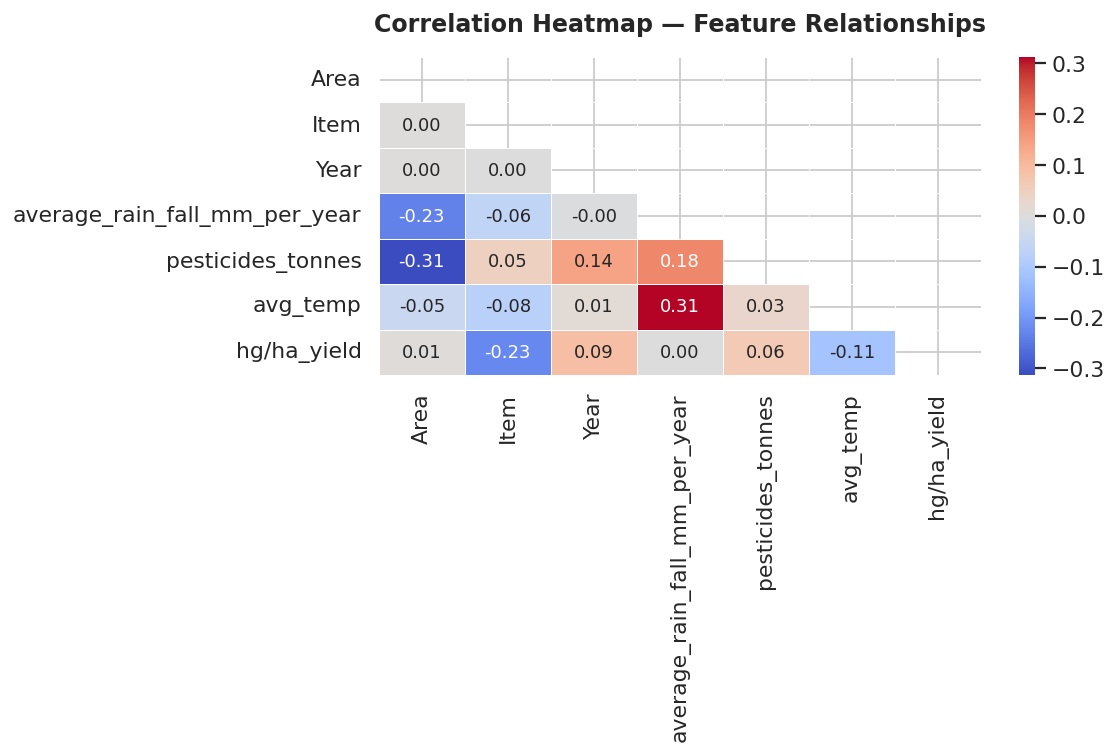

📌 Insight: 'pesticides_tonnes' and 'Area' show the strongest correlation with yield.


In [15]:
# ── 6.1  Correlation Heatmap ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

corr = df_encoded[['Area', 'Item', 'Year',
                    'average_rain_fall_mm_per_year',
                    'pesticides_tonnes', 'avg_temp',
                    'hg/ha_yield']].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))   # hide upper triangle
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5,
            annot_kws={"size": 10}, ax=ax)

ax.set_title("Correlation Heatmap — Feature Relationships", pad=14)
plt.tight_layout()
plt.show()
print("📌 Insight: 'pesticides_tonnes' and 'Area' show the strongest correlation with yield.")

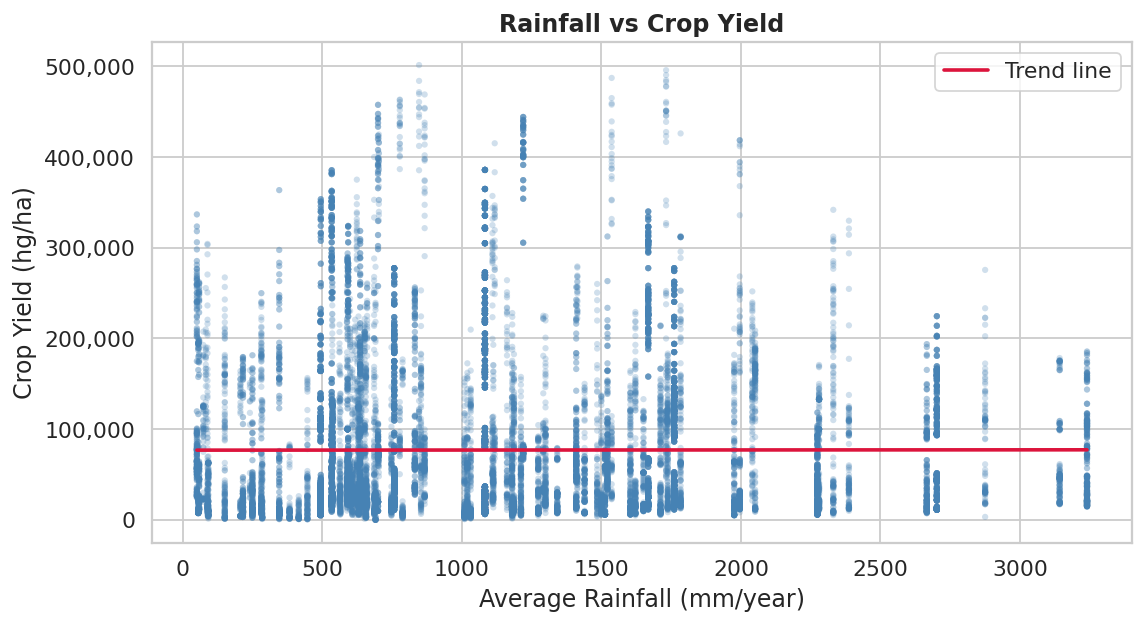

📌 Insight: No strong linear relationship — yield depends on many other factors too.


In [16]:
# ── 6.2  Rainfall vs Yield ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(df['average_rain_fall_mm_per_year'], df['hg/ha_yield'],
           alpha=0.25, s=12, color='steelblue', edgecolors='none')

# Trend line
z = np.polyfit(df['average_rain_fall_mm_per_year'], df['hg/ha_yield'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['average_rain_fall_mm_per_year'].min(),
                     df['average_rain_fall_mm_per_year'].max(), 300)
ax.plot(x_line, p(x_line), color='crimson', linewidth=2, label='Trend line')

ax.set_xlabel("Average Rainfall (mm/year)")
ax.set_ylabel("Crop Yield (hg/ha)")
ax.set_title("Rainfall vs Crop Yield")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend()
plt.tight_layout()
plt.show()
print("📌 Insight: No strong linear relationship — yield depends on many other factors too.")

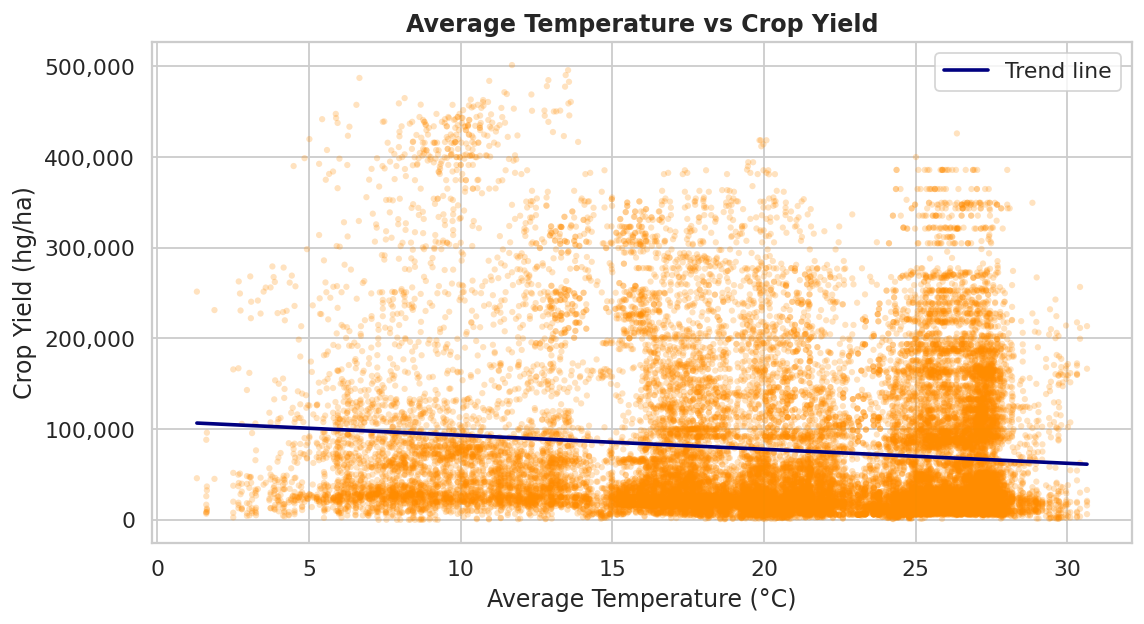

📌 Insight: Higher temperatures show a slight negative effect on yield in some regions.


In [17]:
# ── 6.3  Average Temperature vs Yield ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(df['avg_temp'], df['hg/ha_yield'],
           alpha=0.25, s=12, color='darkorange', edgecolors='none')

z = np.polyfit(df['avg_temp'], df['hg/ha_yield'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['avg_temp'].min(), df['avg_temp'].max(), 300)
ax.plot(x_line, p(x_line), color='navy', linewidth=2, label='Trend line')

ax.set_xlabel("Average Temperature (°C)")
ax.set_ylabel("Crop Yield (hg/ha)")
ax.set_title("Average Temperature vs Crop Yield")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend()
plt.tight_layout()
plt.show()
print("📌 Insight: Higher temperatures show a slight negative effect on yield in some regions.")

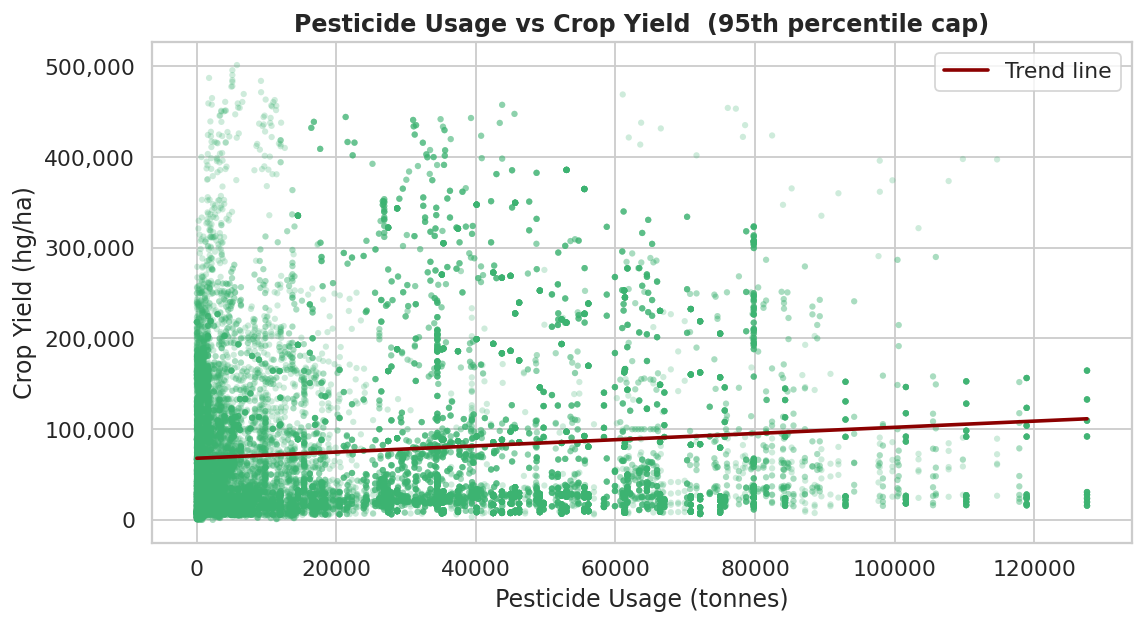

📌 Insight: Higher pesticide use is positively correlated with yield — possibly reflecting intensive farming.


In [18]:
# ── 6.4  Pesticide Usage vs Yield ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

# Cap pesticide axis for clarity (remove extreme outliers visually)
pct_95 = df['pesticides_tonnes'].quantile(0.95)
df_plot = df[df['pesticides_tonnes'] <= pct_95]

ax.scatter(df_plot['pesticides_tonnes'], df_plot['hg/ha_yield'],
           alpha=0.25, s=12, color='mediumseagreen', edgecolors='none')

z = np.polyfit(df_plot['pesticides_tonnes'], df_plot['hg/ha_yield'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_plot['pesticides_tonnes'].min(),
                     df_plot['pesticides_tonnes'].max(), 300)
ax.plot(x_line, p(x_line), color='darkred', linewidth=2, label='Trend line')

ax.set_xlabel("Pesticide Usage (tonnes)")
ax.set_ylabel("Crop Yield (hg/ha)")
ax.set_title("Pesticide Usage vs Crop Yield  (95th percentile cap)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend()
plt.tight_layout()
plt.show()
print("📌 Insight: Higher pesticide use is positively correlated with yield — possibly reflecting intensive farming.")

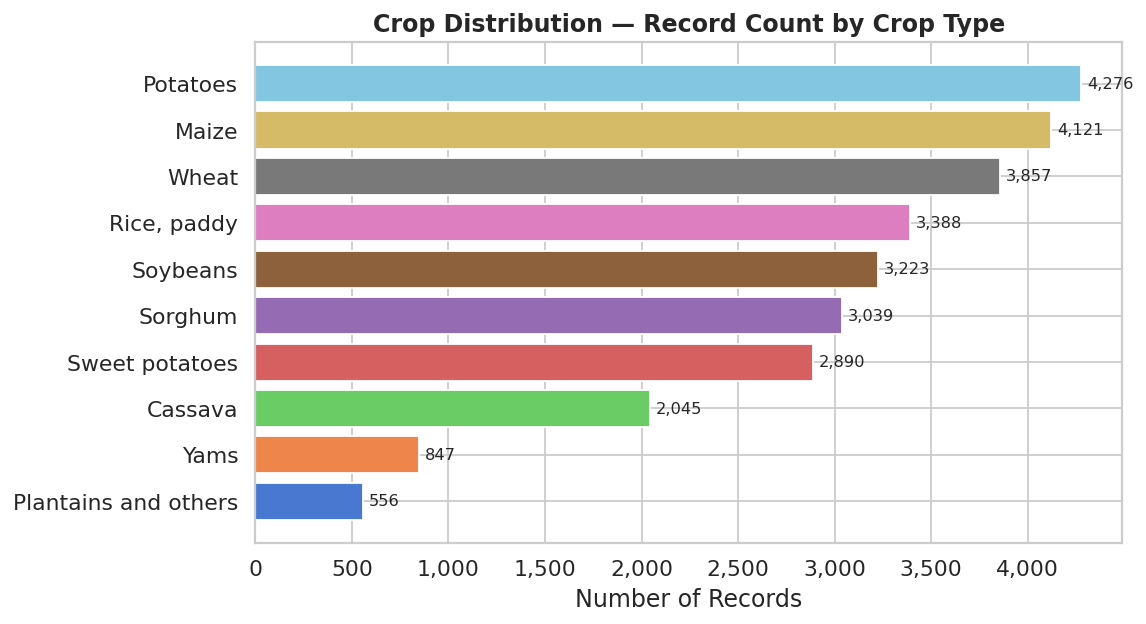

📌 Insight: All 10 crops are fairly uniformly represented in the dataset.


In [19]:
# ── 6.5  Crop Distribution (count of records per crop) ───────────────────────
crop_counts = df['Item'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(crop_counts.index, crop_counts.values,
               color=sns.color_palette("muted", len(crop_counts)))

for bar, val in zip(bars, crop_counts.values):
    ax.text(val + 30, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va='center', fontsize=9)

ax.set_xlabel("Number of Records")
ax.set_title("Crop Distribution — Record Count by Crop Type")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()
print("📌 Insight: All 10 crops are fairly uniformly represented in the dataset.")

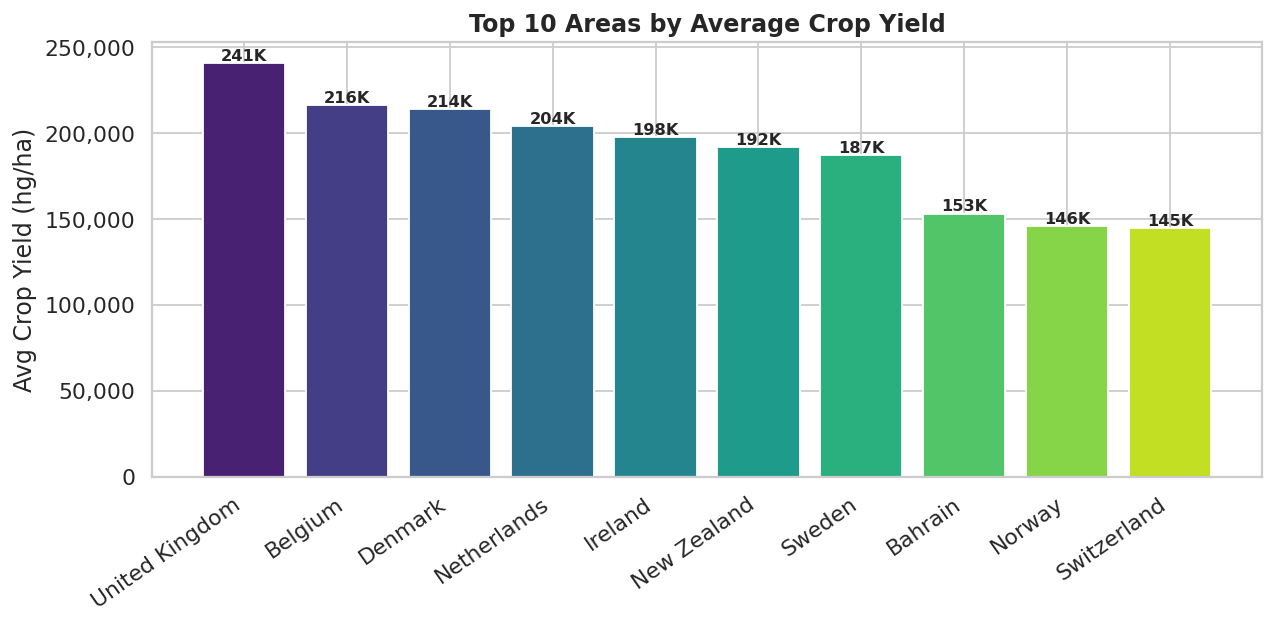

📌 Insight: UK, Belgium and Denmark are among the top-producing areas — reflecting highly optimised agriculture.


In [20]:
# ── 6.6  Top 10 Crop-Producing Areas (by average yield) ──────────────────────
top10 = (df.groupby('Area')['hg/ha_yield']
           .mean()
           .sort_values(ascending=False)
           .head(10))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(top10.index, top10.values,
              color=sns.color_palette("viridis", 10))

for bar, val in zip(bars, top10.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 1500,
            f"{val/1000:.0f}K", ha='center', fontsize=9, fontweight='bold')

ax.set_ylabel("Avg Crop Yield (hg/ha)")
ax.set_title("Top 10 Areas by Average Crop Yield")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()
print("📌 Insight: UK, Belgium and Denmark are among the top-producing areas — reflecting highly optimised agriculture.")

In [21]:
# ── 7.1  Define features (X) and target (y) ──────────────────────────────────
FEATURES = ['Area', 'Item', 'Year',
            'average_rain_fall_mm_per_year',
            'pesticides_tonnes', 'avg_temp']
TARGET   = 'hg/ha_yield'

X = df_encoded[FEATURES]
y = df_encoded[TARGET]

print("Features used for prediction:")
for f in FEATURES:
    print(f"  ✔ {f}")
print(f"\nTarget variable  :  {TARGET}")
print(f"Feature matrix   :  {X.shape}")
print(f"Target vector    :  {y.shape}")

Features used for prediction:
  ✔ Area
  ✔ Item
  ✔ Year
  ✔ average_rain_fall_mm_per_year
  ✔ pesticides_tonnes
  ✔ avg_temp

Target variable  :  hg/ha_yield
Feature matrix   :  (28242, 6)
Target vector    :  (28242,)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("=" * 40)
print("  SPLIT SUMMARY")
print("=" * 40)
print(f"  Training samples : {len(X_train):,}  (80%)")
print(f"  Testing samples  : {len(X_test):,}   (20%)")
print(f"  Total            : {len(X):,}")

  SPLIT SUMMARY
  Training samples : 22,593  (80%)
  Testing samples  : 5,649   (20%)
  Total            : 28,242


In [23]:
# ── 9.1  Linear Regression ───────────────────────────────────────────────────
print("Training Linear Regression …")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("✅ Linear Regression trained!")

Training Linear Regression …
✅ Linear Regression trained!


In [24]:
# ── 9.2  Random Forest Regressor ─────────────────────────────────────────────
# n_estimators = 100 trees for a good balance of accuracy and speed
print("Training Random Forest Regressor (this may take ~30 seconds) …")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("✅ Random Forest trained!")

Training Random Forest Regressor (this may take ~30 seconds) …
✅ Random Forest trained!


In [25]:
# ── Helper function ───────────────────────────────────────────────────────────
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    mae    = mean_absolute_error(y_test, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    r2     = r2_score(y_test, y_pred)
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R² Score": r2,
            "y_pred": y_pred}

# ── Evaluate both models ──────────────────────────────────────────────────────
lr_results = evaluate_model("Linear Regression",    lr_model, X_test, y_test)
rf_results = evaluate_model("Random Forest",         rf_model, X_test, y_test)

# ── Pretty comparison table ───────────────────────────────────────────────────
results_df = pd.DataFrame([
    {k: v for k, v in lr_results.items() if k != "y_pred"},
    {k: v for k, v in rf_results.items() if k != "y_pred"},
])
results_df = results_df.set_index("Model").round(2)

print("=" * 60)
print("  MODEL EVALUATION COMPARISON")
print("=" * 60)
print(results_df.to_string())
print()

best = results_df["R² Score"].idxmax()
print(f"🏆  Best Model (highest R²): {best}")

  MODEL EVALUATION COMPARISON
                        MAE      RMSE  R² Score
Model                                          
Linear Regression  62444.31  81501.76      0.08
Random Forest       3752.48  10181.76      0.99

🏆  Best Model (highest R²): Random Forest


In [34]:
# ── Sample input — modify these values as needed ─────────────────────────────
sample_area       = "Albania"          # Must match a country in the dataset
sample_crop       = "Wheat"            # Must match a crop name in the dataset
sample_rainfall   = 700.0              # mm per year
sample_temperature= 16.5              # °C
sample_pesticides = 121.0             # tonnes
sample_year       = 2010

# ── Encode the inputs the same way the model was trained ─────────────────────
def encode_input(area, crop, year, rainfall, pesticides, temp):
    """Encode a single sample for prediction."""
    area_encoded = le_area.transform([area])[0]
    crop_encoded = le_item.transform([crop])[0]
    return pd.DataFrame([[area_encoded, crop_encoded, year,
                          rainfall, pesticides, temp]],
                        columns=FEATURES)

sample_df = encode_input(sample_area, sample_crop,
                         sample_year, sample_rainfall,
                         sample_pesticides, sample_temperature)

# ── Predictions from both models ──────────────────────────────────────────────
lr_pred = lr_model.predict(sample_df)[0]
rf_pred = rf_model.predict(sample_df)[0]

print("=" * 55)
print("  CUSTOM PREDICTION RESULT")
print("=" * 55)
print(f"  Area          : {sample_area}")
print(f"  Crop          : {sample_crop}")
print(f"  Year          : {sample_year}")
print(f"  Rainfall      : {sample_rainfall} mm/year")
print(f"  Temperature   : {sample_temperature} °C")
print(f"  Pesticides    : {sample_pesticides} tonnes")
print("-" * 55)
print(f"  Linear Regression Prediction : {lr_pred:>12,.1f} hg/ha")
print(f"  Random Forest Prediction     : {rf_pred:>12,.1f} hg/ha")
print("=" * 55)
print(f"  (1 hg/ha ≈ 0.1 kg/ha — typical wheat yield: ~30,000–50,000 hg/ha)")

  CUSTOM PREDICTION RESULT
  Area          : Albania
  Crop          : Wheat
  Year          : 2010
  Rainfall      : 700.0 mm/year
  Temperature   : 16.5 °C
  Pesticides    : 121.0 tonnes
-------------------------------------------------------
  Linear Regression Prediction :     56,264.9 hg/ha
  Random Forest Prediction     :     31,285.5 hg/ha
  (1 hg/ha ≈ 0.1 kg/ha — typical wheat yield: ~30,000–50,000 hg/ha)
